Before continuing with the pipeline, we must be verify that much of the residuals behave like idiosyncratic returns should. For stock $i$ over a rolling window of $T = 252$ observations, define the excess return vector and factor matrix

$$\tilde{\mathbf{r}}^i = \mathbf{r}^i - \mathbf{rf} \in \mathbb{R}^T \qquad \mathbf{F} = \begin{pmatrix} 1 & f_1^\top \\ \vdots & \vdots \\ 1 & f_T^\top \end{pmatrix} \in \mathbb{R}^{T \times 7}$$

where $f_t = (\text{MktRF}_t, \text{SMB}_t, \text{HML}_t, \text{RMW}_t, \text{CMA}_t, \text{Mom}_t)^\top \in \mathbb{R}^6$. The OLS estimator

$$\hat{\boldsymbol{\theta}}^i = (\mathbf{F}^\top \mathbf{F})^{-1} \mathbf{F}^\top \tilde{\mathbf{r}}^i \in \mathbb{R}^7$$

The residual vector via the annihilator matrix $\mathbf{M}_F = \mathbf{I}_T - \mathbf{F}(\mathbf{F}^\top\mathbf{F})^{-1}\mathbf{F}^\top$

$$\hat{\boldsymbol{\epsilon}}^i = \mathbf{M}_F \tilde{\mathbf{r}}^i \qquad \text{with} \qquad \mathbf{F}^\top \hat{\boldsymbol{\epsilon}}^i = \mathbf{0}$$


In [1]:
import os
import sys; sys.path.append('..')
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from src.signals.residuals import load_residuals
from src.data.factors import load_factors, FACTOR_COLS

plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

R = load_residuals()
F = load_factors()
print(f'Residuals: {R.shape} | Factors: {F.shape}')

Residuals: (3419626, 11) | Factors: (5344, 8)


Within each estimation window, $\mathbf{F}^\top \hat{\boldsymbol{\epsilon}}^i = \mathbf{0}$ exactly by construction of OLS (Frisch-Waugh-Lovell). Across the full rolling panel the betas shift daily, so the population analog holds approximately

$$\mathbb{E}[\epsilon_t^i \cdot f_t^k] = 0 \quad \forall k \in \{1,\ldots,6\}$$

We test this by computing $\rho(\bar{\epsilon}_t, f_t^k)$ where $\bar{\epsilon}_t = \frac{1}{N_t}\sum_i \epsilon_t^i$ is the daily cross-sectional mean residual. Any $|\rho| > 0.05$ signals a date alignment bug between returns and factors.

Reference: Fama & MacBeth (1973, *JPE*).

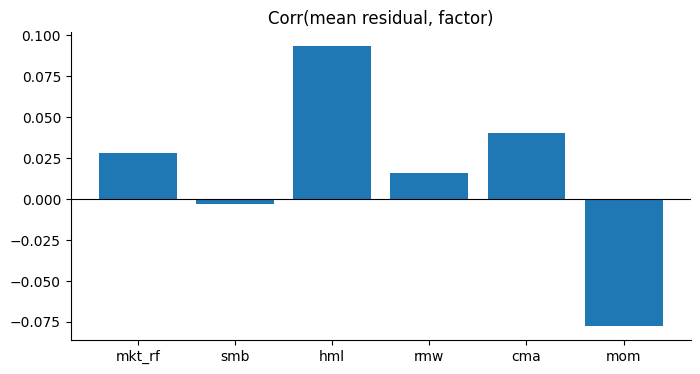

{'mkt_rf': np.float64(0.028321065533508015),
 'smb': np.float64(-0.0029013767788759913),
 'hml': np.float64(0.09346802340462539),
 'rmw': np.float64(0.015672934413907193),
 'cma': np.float64(0.04012492072870558),
 'mom': np.float64(-0.07767388706414133)}

In [2]:
daily = R.group_by('date').agg(pl.col('residual').mean()).join(F, on='date', how='inner')
corrs = {c: np.corrcoef(daily['residual'], daily[c])[0,1] for c in FACTOR_COLS}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(corrs.keys(), corrs.values())
ax.axhline(0, color='k', linewidth=0.8)
ax.set_title('Corr(mean residual, factor)')
save_fig("01_residuals_corr_mean_residual.png")
plt.show()

corrs

The rolling estimator $\hat{\boldsymbol{\theta}}_t^i = (\mathbf{F}_t^\top \mathbf{F}_t)^{-1} \mathbf{F}_t^\top \tilde{\mathbf{r}}_t^i$ where the subscript $t$ denotes the trailing 252-day window ending on date $t$.

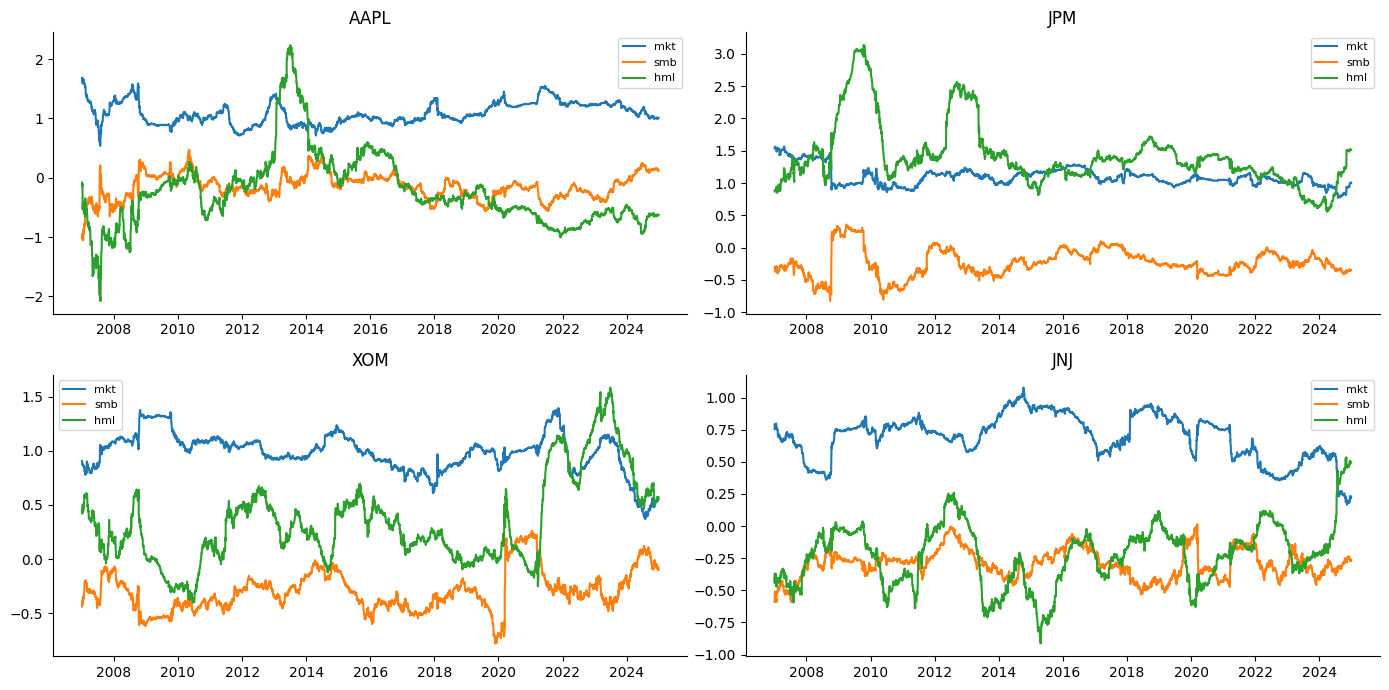

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, t in zip(axes.flat, ['AAPL', 'JPM', 'XOM', 'JNJ']):
    d = R.filter(pl.col('symbol') == t).sort('date')
    for col, lbl in [('beta_mkt','mkt'), ('beta_smb','smb'), ('beta_hml','hml')]:
        ax.plot(d['date'].to_list(), d[col].to_list(), label=lbl)
    ax.set_title(t)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig("01_residuals_beta_paths.png")
plt.show()

Stack all residuals into $\mathbf{E} \in \mathbb{R}^{T \times N}$. The empirical distribution of $\text{vec}(\mathbf{E})$ should be symmetric with fat tails

$$\gamma_1 = \frac{\mathbb{E}[(\epsilon - \mu)^3]}{\sigma^3} \approx 0 \qquad \gamma_2 = \frac{\mathbb{E}[(\epsilon - \mu)^4]}{\sigma^4} - 3 \in [5, 15]$$

QQ should be pronounced.

Reference: Fama (1965, *Journal of Business*).

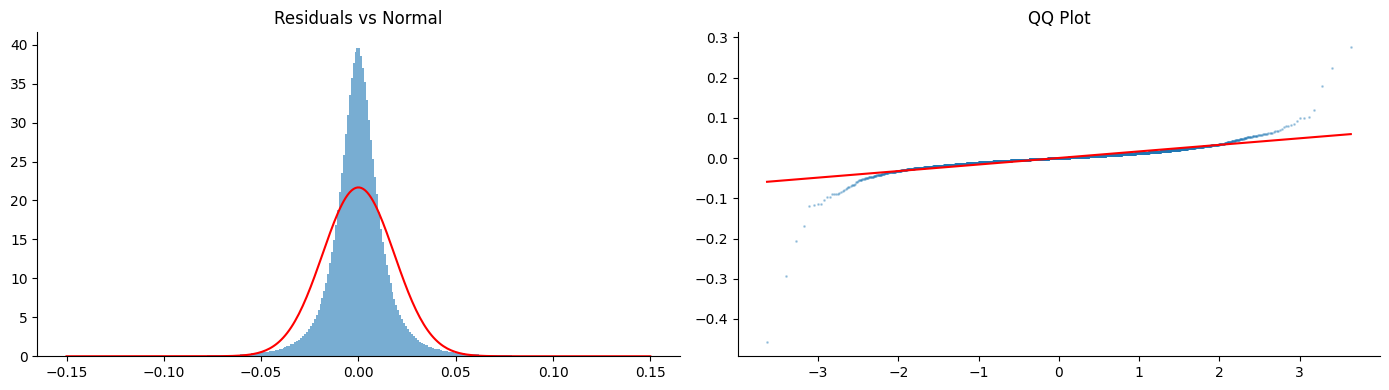

Skewness: -0.1792  |  Excess kurtosis: 70.2480


In [4]:
e = R['residual'].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(e, bins=300, density=True, range=(-0.15, 0.15), alpha=0.6)
x = np.linspace(-0.15, 0.15, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, e.std()), 'r-')
axes[0].set_title('Residuals vs Normal')

sample = np.random.choice(e, 5000, replace=False)
(osm, osr), (slope, intercept, _) = stats.probplot(sample, dist='norm')
axes[1].scatter(osm, osr, s=1, alpha=0.3)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-')
axes[1].set_title('QQ Plot')

plt.tight_layout()
save_fig("01_residuals_hist_qq.png")
plt.show()

print(f'Skewness: {stats.skew(e):.4f}  |  Excess kurtosis: {stats.kurtosis(e):.4f}')

The coefficient of determination for stock $i$ on window $t$:

$$R_t^{i2} = 1 - \frac{\hat{\boldsymbol{\epsilon}}_t^{i\top} \hat{\boldsymbol{\epsilon}}_t^i}{\tilde{\mathbf{r}}_t^{i\top} \mathbf{M}_\mathbf{1} \tilde{\mathbf{r}}_t^i}$$

where $\mathbf{M}_\mathbf{1} = \mathbf{I} - \frac{1}{T}\mathbf{1}\mathbf{1}^\top$ demeans the dependent variable. The factor model explains more variance for stable sectors (utilities, staples) than idiosyncratic ones (tech, biotech). Documented in the MSCI Barra USE4 methodology for their production risk model.

In [5]:
SECTOR_MAP = {
    'AAPL':'Tech',   'MSFT':'Tech',   'NVDA':'Tech',   'AMD':'Tech',
    'JPM':'Finance', 'BAC':'Finance', 'GS':'Finance',  'MS':'Finance',
    'JNJ':'Health',  'PFE':'Health',  'MRK':'Health',  'UNH':'Health',
    'XOM':'Energy',  'CVX':'Energy',  'COP':'Energy',  'SLB':'Energy',
    'NEE':'Utility', 'DUK':'Utility', 'SO':'Utility',  'AEP':'Utility',
    'PG':'Staples',  'KO':'Staples',  'PEP':'Staples', 'WMT':'Staples',
}
rows = [{'sector': s, 'r2': R.filter(pl.col('symbol')==t)['r_squared'].mean()}
        for t, s in SECTOR_MAP.items() if len(R.filter(pl.col('symbol')==t)) > 0]
means = pl.DataFrame(rows).group_by('sector').agg(pl.col('r2').mean()).sort('r2', descending=True)

means

sector,r2
str,f64
"""Finance""",0.717982
"""Energy""",0.600228
"""Tech""",0.498453
"""Staples""",0.410924
"""Health""",0.389537
"""Utility""",0.354911


The annualized idiosyncratic volatility is the scaling term in the Grinold-Kahn alpha

$$\alpha_i = IC \cdot \sigma_i \cdot z_i^* \qquad \hat{\sigma}_i = \sqrt{252} \cdot \left(\frac{1}{T-1}\hat{\boldsymbol{\epsilon}}_i^\top \mathbf{M}_\mathbf{1} \hat{\boldsymbol{\epsilon}}_i\right)^{1/2}$$

Reference: Ang, Hodrick, Xing & Zhang (2006, *JF*)

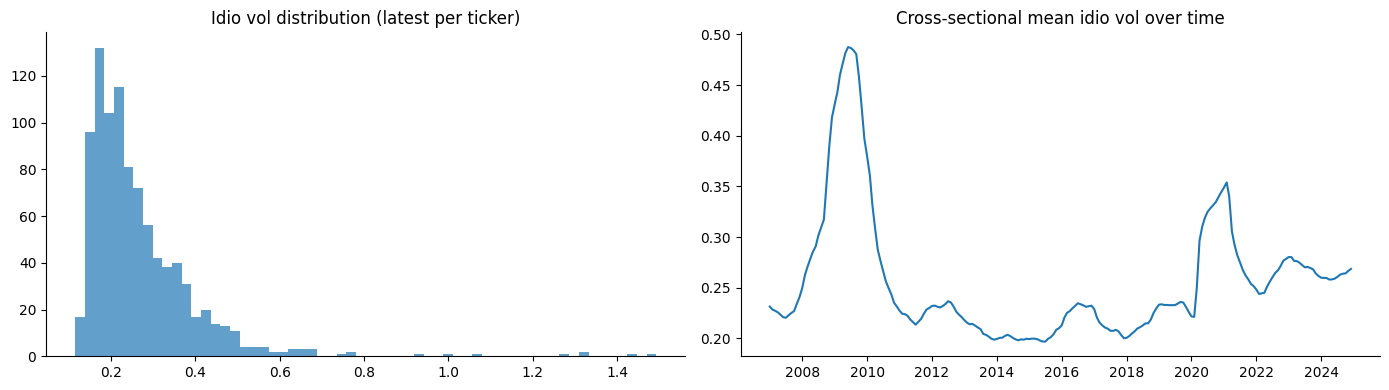

Mean: 26.85%  |  Median: 23.07%  |  p90: 41.37%


In [6]:
v = R.sort('date').group_by('symbol').agg(pl.col('idio_vol').last())['idio_vol'].to_numpy()
v = v[v < 2.0]

monthly = (R.with_columns(pl.col('date').dt.month_start().alias('m'))
            .group_by('m').agg(pl.col('idio_vol').mean()).sort('m'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(v, bins=60, alpha=0.7)
axes[0].set_title('Idio vol distribution (latest per ticker)')
axes[1].plot(monthly['m'].to_list(), monthly['idio_vol'].to_list())
axes[1].set_title('Cross-sectional mean idio vol over time')
plt.tight_layout()
save_fig("01_residuals_idio_vol.png")
plt.show()

print(f'Mean: {v.mean():.2%}  |  Median: {np.median(v):.2%}  |  p90: {np.percentile(v,90):.2%}')

Stack the cross-sectional residual vector $\boldsymbol{\epsilon}_t = (\epsilon_t^1, \ldots, \epsilon_t^{N_t})^\top \in \mathbb{R}^{N_t}$. Its dispersion on date $t$

$$\text{CSD}_t = \left(\frac{1}{N_t - 1} \boldsymbol{\epsilon}_t^\top \mathbf{M}_\mathbf{1} \boldsymbol{\epsilon}_t\right)^{1/2}$$

where $\mathbf{M}_\mathbf{1}$ demeans cross-sectionally.

Reference: Bekaert, Hodrick & Zhang (2012, *RFS*). Campbell, Lettau, Malkiel & Xu (2001, *JF*).

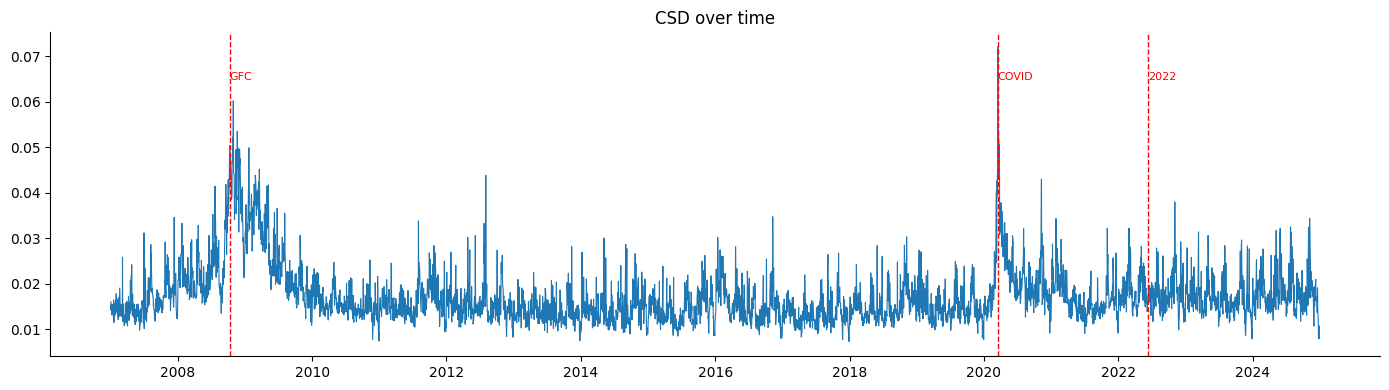

date,csd
date,f64
2020-03-17,0.072048
2008-10-29,0.060237
2008-10-30,0.060204
2020-03-20,0.053822
2008-11-20,0.053523


In [7]:
from datetime import date
csd = R.group_by('date').agg(pl.col('residual').std().alias('csd')).sort('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(csd['date'].to_list(), csd['csd'].to_numpy(), linewidth=0.8)
for d, lbl in [(date(2008,10,10),'GFC'), (date(2020,3,16),'COVID'), (date(2022,6,13),'2022')]:
    ax.axvline(d, color='r', linestyle='--', linewidth=1)
    ax.text(d, csd['csd'].max()*0.9, lbl, fontsize=8, color='r')
ax.set_title('CSD over time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig("01_residuals_csd_over_time.png")
plt.show()

csd.sort('csd', descending=True).head(5)

The lag-1 autocorrelation of the residual time series for stock $i$

$$\rho_1^i = \frac{\hat{\boldsymbol{\epsilon}}_{2:T}^{i\top} \mathbf{M}_\mathbf{1} \hat{\boldsymbol{\epsilon}}_{1:T-1}^i}{\hat{\boldsymbol{\epsilon}}^{i\top} \mathbf{M}_\mathbf{1} \hat{\boldsymbol{\epsilon}}^i}$$

where $\hat{\boldsymbol{\epsilon}}_{2:T}^i$ denotes the residual vector with the first observation dropped and $\hat{\boldsymbol{\epsilon}}_{1:T-1}^i$ denotes it with the last observation dropped.

Reference: Lo & MacKinlay (1988, *RFS*). Jegadeesh (1990, *JF*).

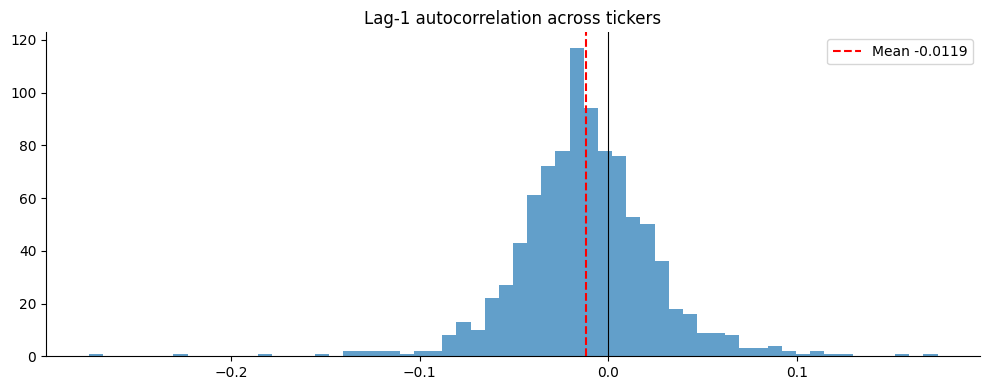

Mean: -0.0119  |  % positive: 32.8%


In [8]:
rhos = []
for t in R['symbol'].unique().to_list():
    e = R.filter(pl.col('symbol')==t).sort('date')['residual'].to_numpy()
    if len(e) > 10:
        rhos.append(np.corrcoef(e[1:], e[:-1])[0,1])
rhos = np.array(rhos)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rhos, bins=60, alpha=0.7)
ax.axvline(rhos.mean(), color='r', linestyle='--', label=f'Mean {rhos.mean():.4f}')
ax.axvline(0, color='k', linewidth=0.8)
ax.set_title('Lag-1 autocorrelation across tickers')
ax.legend()
plt.tight_layout()
save_fig("01_residuals_lag1_autocorr.png")
plt.show()

print(f'Mean: {rhos.mean():.4f}  |  % positive: {(rhos>0).mean():.1%}')

Everything is pretty standard.